Exploratory Data Analysis (EDA)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Dataset Overview

In [37]:
df = pd.read_csv("retail_large_dataset.csv")
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [38]:
print(df.head())

  customer_id  age  gender       city        state customer_segment order_id  \
0      C10000   56    Male  Hyderabad    Telangana              New   O50000   
1      C10001   36    Male       Pune  Maharashtra          Premium   O50001   
2      C10002   20    Male    Kolkata  West Bengal              New   O50002   
3      C10003   39  Female     Jaipur    Rajasthan              New   O50003   
4      C10004   20    Male    Chennai   Tamil Nadu          Premium   O50004   

   order_date product_category product_subcategory  product_price  quantity  \
0  2025-05-10           Health      Protein Powder          38658         3   
1  2023-11-27      Electronics          Smartphone          22462         4   
2  2025-02-08          Fashion         Women Dress          56601         2   
3  2024-04-19           Beauty             Perfume          26158         3   
4  2024-10-08           Beauty             Shampoo          31240         1   

   discount_percentage  final_price    payme

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  str    
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  str    
 3   city                 100000 non-null  str    
 4   state                100000 non-null  str    
 5   customer_segment     100000 non-null  str    
 6   order_id             100000 non-null  str    
 7   order_date           100000 non-null  str    
 8   product_category     100000 non-null  str    
 9   product_subcategory  100000 non-null  str    
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  str    
 15  shipping_type        100000 n

In [40]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nColumns:\n", df.columns.tolist())

Rows: 100000
Columns: 18

Data Types:
 customer_id                str
age                      int64
gender                     str
city                       str
state                      str
customer_segment           str
order_id                   str
order_date                 str
product_category           str
product_subcategory        str
product_price            int64
quantity                 int64
discount_percentage      int64
final_price            float64
payment_method             str
shipping_type              str
delivery_days            int64
return_status              str
dtype: object

Missing Values:
 customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method       

In [41]:
# Check Duplicate
print("\n--- Duplicate Check---")
print(f"Total duplicates: {df.duplicated().sum()}")
print(f"Duplicate %: {df.duplicated().sum()/len(df) * 100:.2f}%")
print(df.duplicated().sum())


--- Duplicate Check---
Total duplicates: 0
Duplicate %: 0.00%
0


In [42]:
# Remobve duplicates if any
df_before = df.shape[0]
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]} rows "
    f"(Removed {df_before - df.shape[0]})")

After removing duplicates: 100000 rows (Removed 0)


In [43]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [44]:
df['customer_id'].duplicated().sum()

np.int64(0)

In [45]:
df.describe()

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,30164.526720,2.501790,15.009890,64165.723382,5.505540
std,13.852439,17139.679807,1.120058,8.953296,49969.280150,2.872868
min,18.000000,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,59998.000000,4.000000,30.000000,239980.000000,10.000000


In [46]:
# Summary statistics for categorical (text) columns
print(df.describe(include=['object', 'string']))

       customer_id  gender       city        state customer_segment order_id  \
count       100000  100000     100000       100000           100000   100000   
unique      100000       2         10            9                3   100000   
top         C10000    Male  Hyderabad  Maharashtra              New   O50000   
freq             1   50111      10150        19952            33488        1   

        order_date product_category product_subcategory payment_method  \
count       100000           100000              100000         100000   
unique        1095                6                  21              4   
top     2023-04-12           Health      Protein Powder    Credit Card   
freq           124            16858                5668          25307   

       shipping_type return_status  
count         100000        100000  
unique             2             2  
top          Express            No  
freq           50008         85189  


In [47]:
print(df.describe(include='all'))

       customer_id            age  gender       city        state  \
count       100000  100000.000000  100000     100000       100000   
unique      100000            NaN       2         10            9   
top         C10000            NaN    Male  Hyderabad  Maharashtra   
freq             1            NaN   50111      10150        19952   
mean           NaN      41.561830     NaN        NaN          NaN   
std            NaN      13.852439     NaN        NaN          NaN   
min            NaN      18.000000     NaN        NaN          NaN   
25%            NaN      30.000000     NaN        NaN          NaN   
50%            NaN      42.000000     NaN        NaN          NaN   
75%            NaN      54.000000     NaN        NaN          NaN   
max            NaN      65.000000     NaN        NaN          NaN   

       customer_segment order_id  order_date product_category  \
count            100000   100000      100000           100000   
unique                3   100000        1

In [48]:
# Fetching the unique values

print("\n--- First 9 rows ---")
print(df.head())


--- First 9 rows ---
  customer_id  age  gender       city        state customer_segment order_id  \
0      C10000   56    Male  Hyderabad    Telangana              New   O50000   
1      C10001   36    Male       Pune  Maharashtra          Premium   O50001   
2      C10002   20    Male    Kolkata  West Bengal              New   O50002   
3      C10003   39  Female     Jaipur    Rajasthan              New   O50003   
4      C10004   20    Male    Chennai   Tamil Nadu          Premium   O50004   

   order_date product_category product_subcategory  product_price  quantity  \
0  2025-05-10           Health      Protein Powder          38658         3   
1  2023-11-27      Electronics          Smartphone          22462         4   
2  2025-02-08          Fashion         Women Dress          56601         2   
3  2024-04-19           Beauty             Perfume          26158         3   
4  2024-10-08           Beauty             Shampoo          31240         1   

   discount_percentage

In [49]:
print("\n--- Last 7 rows ---")
print(df.tail())


--- Last 7 rows ---
      customer_id  age  gender     city        state customer_segment  \
99995     C109995   29  Female     Pune  Maharashtra          Regular   
99996     C109996   28    Male   Mumbai  Maharashtra          Premium   
99997     C109997   44  Female   Jaipur    Rajasthan          Premium   
99998     C109998   45    Male   Jaipur    Rajasthan          Premium   
99999     C109999   19    Male  Kolkata  West Bengal              New   

      order_id  order_date product_category product_subcategory  \
99995  O149995  2024-06-11           Health         Supplements   
99996  O149996  2024-04-27          Fashion         Men T-Shirt   
99997  O149997  2024-04-14          Grocery              Snacks   
99998  O149998  2024-09-08           Beauty             Shampoo   
99999  O149999  2025-11-15           Health         Supplements   

       product_price  quantity  discount_percentage  final_price  \
99995          49293         1                   11     43870.77   
9

In [50]:
print("\n--- Random 6 rows ---")
print(df.sample(6))


--- Random 6 rows ---
      customer_id  age  gender       city          state customer_segment  \
34341      C44341   59    Male      Noida  Uttar Pradesh          Premium   
69829      C79829   47  Female  Hyderabad      Telangana          Regular   
31124      C41124   60  Female    Kolkata    West Bengal          Premium   
2048       C12048   54  Female      Noida  Uttar Pradesh          Regular   
61903      C71903   26    Male  Ahmedabad        Gujarat              New   
23598      C33598   62    Male    Kolkata    West Bengal          Regular   

      order_id  order_date product_category product_subcategory  \
34341   O84341  2025-11-14   Home & Kitchen            Cookware   
69829  O119829  2023-02-11          Fashion               Shoes   
31124   O81124  2023-04-24   Home & Kitchen           Microwave   
2048    O52048  2025-01-17           Beauty             Shampoo   
61903  O111903  2025-08-01          Grocery              Snacks   
23598   O73598  2023-01-27         

In [51]:
print(df[df['customer_segment'] == 'Premium'].head(3))

   customer_id  age gender       city        state customer_segment order_id  \
1       C10001   36   Male       Pune  Maharashtra          Premium   O50001   
4       C10004   20   Male    Chennai   Tamil Nadu          Premium   O50004   
11      C10011   61   Male  Ahmedabad      Gujarat          Premium   O50011   

    order_date product_category product_subcategory  product_price  quantity  \
1   2023-11-27      Electronics          Smartphone          22462         4   
4   2024-10-08           Beauty             Shampoo          31240         1   
11  2025-12-22           Health            Vitamins           5758         3   

    discount_percentage  final_price    payment_method shipping_type  \
1                    20     71878.40  Cash on Delivery      Standard   
4                     6     29365.60               UPI      Standard   
11                   16     14510.16        Debit Card       Express   

    delivery_days return_status  
1               4           Yes  
4

In [52]:
print(df[df['final_price'] > 20000].head(3))

  customer_id  age gender       city        state customer_segment order_id  \
0      C10000   56   Male  Hyderabad    Telangana              New   O50000   
1      C10001   36   Male       Pune  Maharashtra          Premium   O50001   
2      C10002   20   Male    Kolkata  West Bengal              New   O50002   

   order_date product_category product_subcategory  product_price  quantity  \
0  2025-05-10           Health      Protein Powder          38658         3   
1  2023-11-27      Electronics          Smartphone          22462         4   
2  2025-02-08          Fashion         Women Dress          56601         2   

   discount_percentage  final_price    payment_method shipping_type  \
0                    7    107855.82        Debit Card      Standard   
1                   20     71878.40  Cash on Delivery      Standard   
2                   27     82637.46       Credit Card      Standard   

   delivery_days return_status  
0              5            No  
1              

In [53]:
# Info & Missing Values
print("\n--- Info ---")
print(df.info())


--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  str    
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  str    
 3   city                 100000 non-null  str    
 4   state                100000 non-null  str    
 5   customer_segment     100000 non-null  str    
 6   order_id             100000 non-null  str    
 7   order_date           100000 non-null  str    
 8   product_category     100000 non-null  str    
 9   product_subcategory  100000 non-null  str    
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  str    
 15  shipping_type  

In [54]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64


2. Univariate Analysis - Numerical

In [55]:
# Combined statistical summary
num_cols = ['product_price', 'discount_percentage', 'final_price', 'quantity']

num_df = df[num_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max', 'skew', lambda x: x.kurtosis()])
num_df.rename(index={'<lambda>': 'kurtosis'}, inplace=True)

print(num_df)

          product_price  discount_percentage    final_price       quantity
count     100000.000000        100000.000000  100000.000000  100000.000000
mean       30164.526720            15.009890   64165.723382       2.501790
median     30148.000000            15.000000   49752.390000       3.000000
std        17139.679807             8.953296   49969.280150       1.120058
min          500.000000             0.000000     357.000000       1.000000
max        59998.000000            30.000000  239980.000000       4.000000
skew           0.003249            -0.003597       0.934747      -0.003067
kurtosis      -1.195106            -1.201628       0.169047      -1.364612


product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64


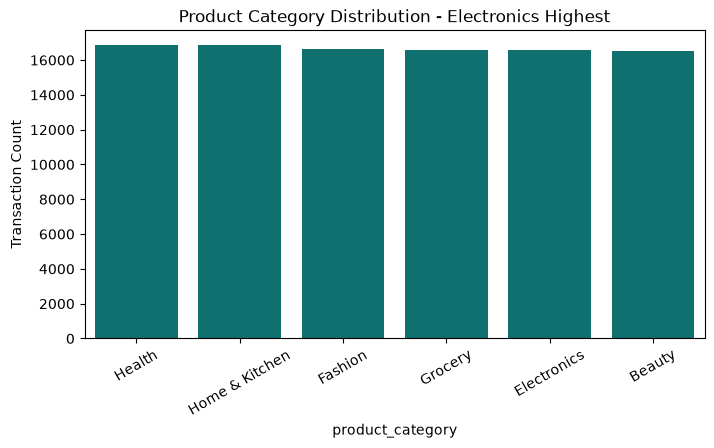


Electronics is highest: 16858 transactions (16.9%)


In [56]:
# product_category
product_category_counts = df['product_category'].value_counts()
print(product_category_counts)
plt.figure(figsize=(8,4))
sns.countplot(
    x='product_category',
    data=df,
    order=product_category_counts.index,
    color='teal'
)
plt.title('Product Category Distribution - Electronics Highest')
plt.xticks(rotation=30)
plt.ylabel('Transaction Count')
plt.show()

print(f"\nElectronics is highest: {df['product_category'].value_counts().iloc[0]} transactions ({df['product_category'].value_counts(normalize=True).iloc[0]*100:.1f}%)")

In [57]:
# Payment method
payment_method_counts = df['payment_method'].value_counts()
print(payment_method_counts)

payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64


customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64


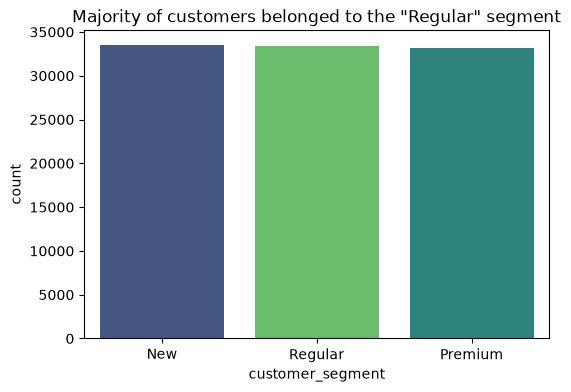

In [58]:
# customer_segment
customer_segment_counts = df['customer_segment'].value_counts()
print(customer_segment_counts)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='customer_segment', data=df, order=customer_segment_counts.index, 
              hue='customer_segment', palette='viridis', legend=False)
plt.title('Majority of customers belonged to the "Regular" segment')
plt.show()

return_status
No     85189
Yes    14811
Name: count, dtype: int64
return_status
No     85.189
Yes    14.811
Name: proportion, dtype: float64
Return Rate: 14.8%
Return rate was approximately 14.8% - (14811 out of 100000)


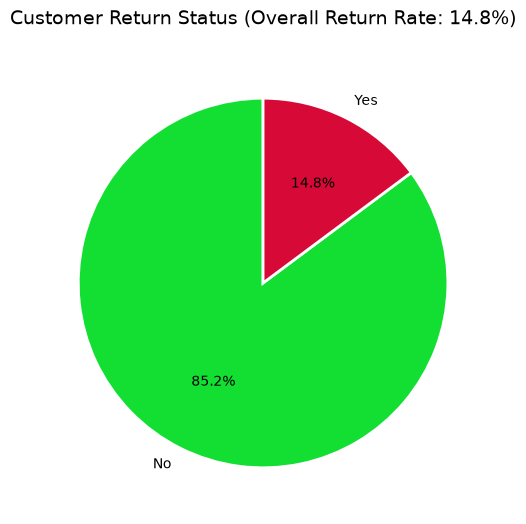

In [59]:
#  return_status
status_counts = df['return_status'].value_counts()
print(status_counts)
print(df['return_status'].value_counts(normalize=True)*100) # %

# Return rate
return_rate = df['return_status'].value_counts(normalize=True).get('Yes', 0) * 100
print(f"Return Rate: {return_rate:.1f}%")

# Calculate exact %
returned_count = status_counts.get('Yes', 0)
total = len(df)
print(f"Return rate was approximately {returned_count/total*100:.1f}% - ({returned_count} out of {total})")

# 2. Plotting the Pie Chart
plt.figure(figsize=(6, 6))
colors = ["#13DF32", "#D70936"] 

plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors[:len(status_counts)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title(f'Customer Return Status (Overall Return Rate: {return_rate:.1f}%)', fontsize=14, pad=20)
plt.show()

3. Univariate Plots

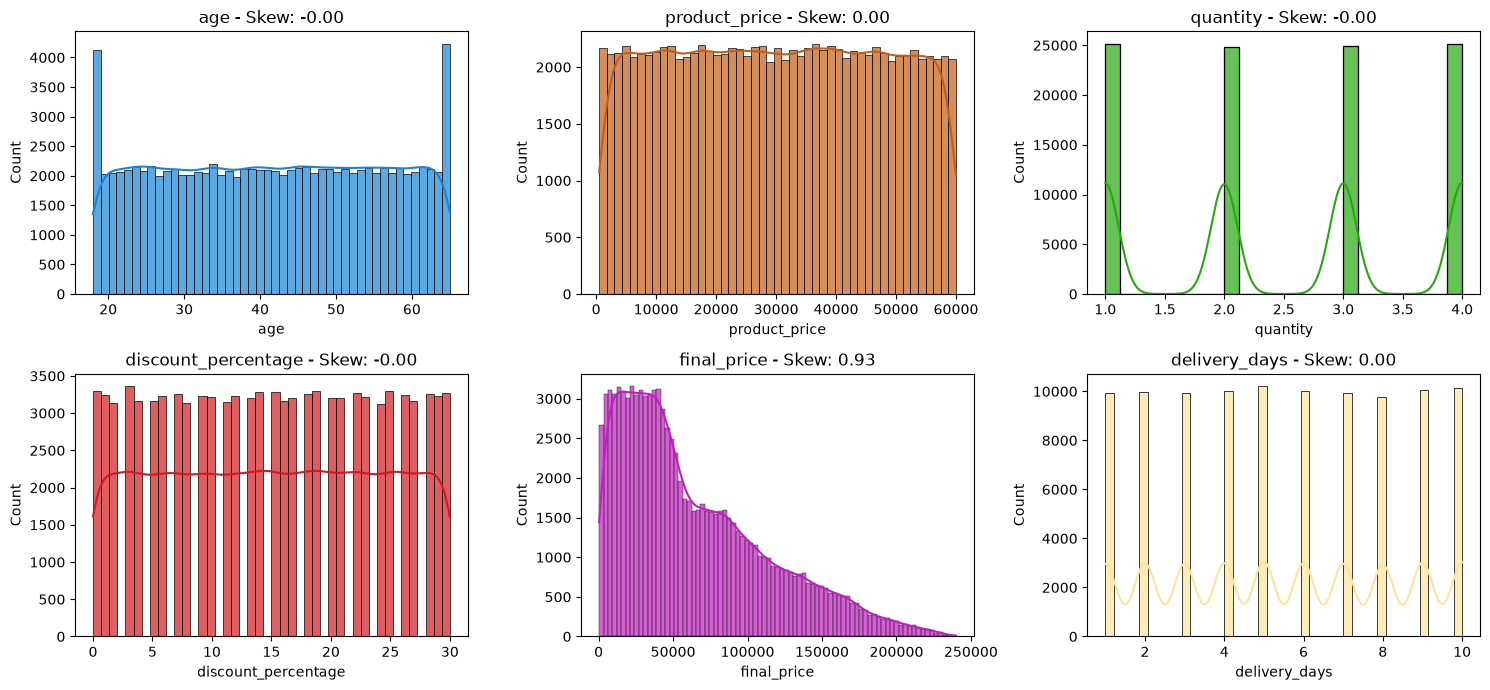

In [60]:
# Histograms + KDE

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if 'id' not in c.lower() and 'ID' not in c]
cols = 3
rows = int(np.ceil(len(num_cols) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3.5))
axes = axes.flatten()
colors = ["#1984D5", "#C35D19", "#25A90E", "#D11A20", "#C11EC1", "#FDE49C"]
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i % len(colors)], alpha=0.7, line_kws={"color": "#16499C"})
    axes[i].set_title(f"{col} - Skew: {df[col].skew():.2f}")

plt.tight_layout()
plt.show()

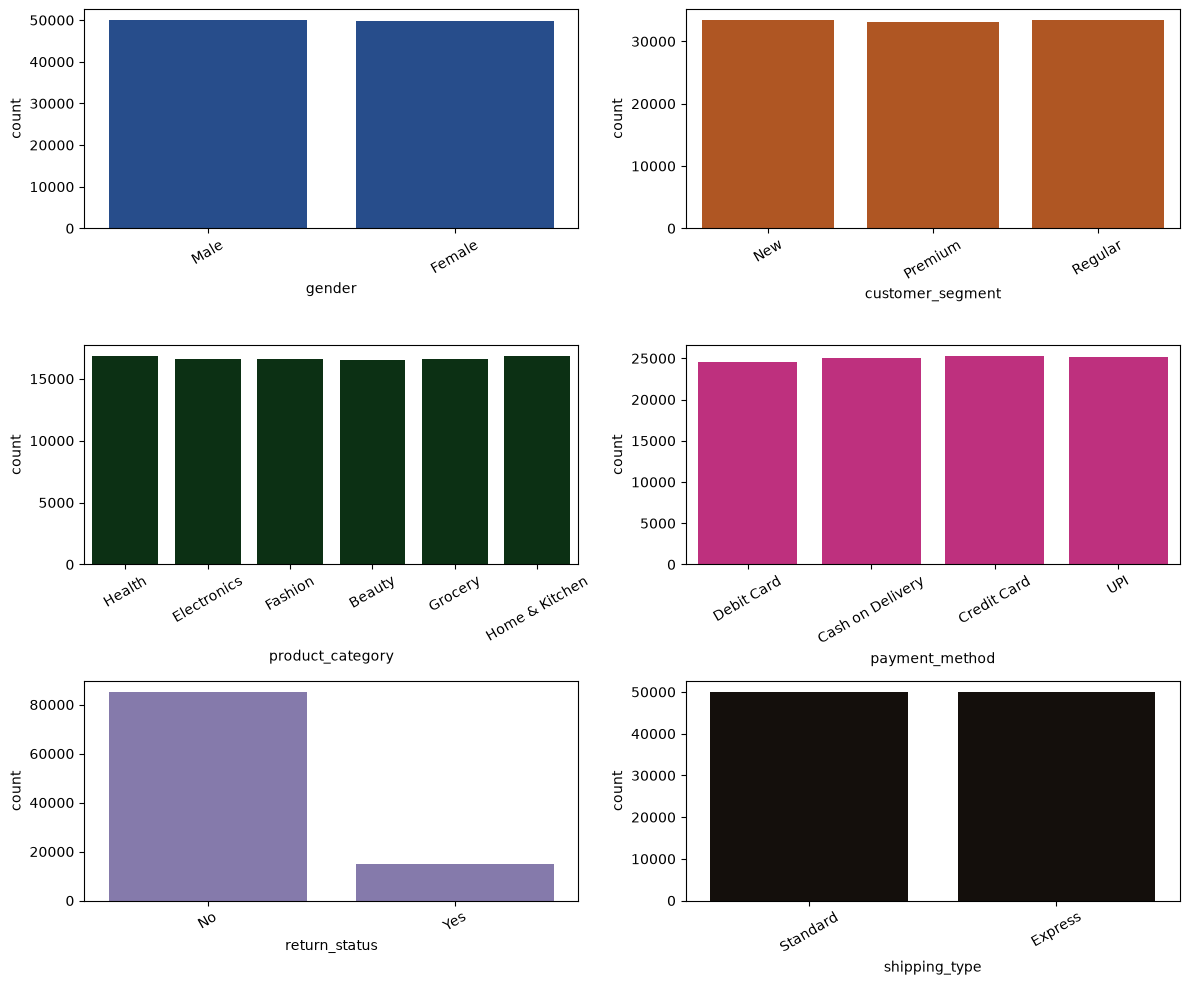

Return Rate: return_status
No     85.189
Yes    14.811
Name: proportion, dtype: float64


In [61]:
# Categorical Univariate
cat_cols = ['gender','customer_segment','product_category','payment_method','return_status','shipping_type']
fig, axes = plt.subplots(3,2, figsize=(12,10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    single_colors = ["#16499C", "#C6500C", "#063611", "#D61881", '#8172B3', "#160F0A"]
    sns.countplot(x=col, data=df, ax=axes[i], color=single_colors[i])
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print("Return Rate:", df['return_status'].value_counts(normalize=True)*100)


4. Outlier Detection

IQR Outliers in final_price: 1335 (1.33%)
Reason: High quantity + Premium category = valid transactions, not to be removed immediately
Z-score >3 outliers: 503


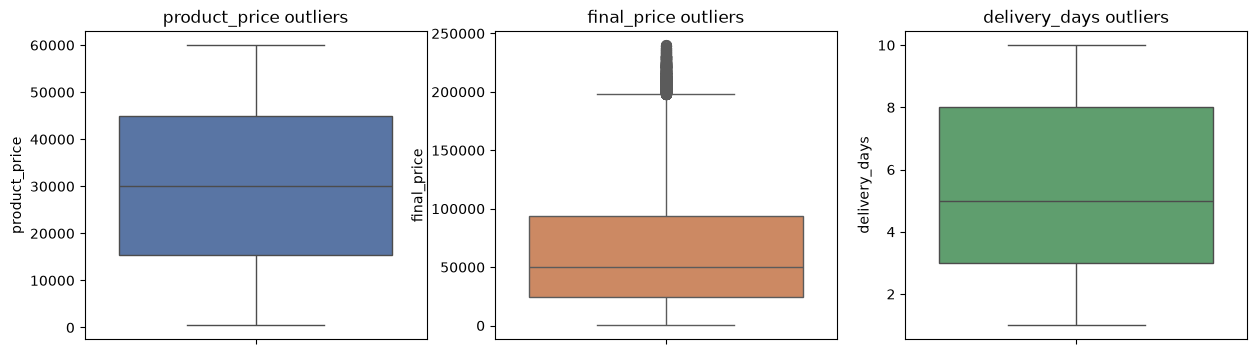

In [62]:
# Boxplot method
plt.figure(figsize=(15,4))
plt.subplot(1,3,1); sns.boxplot(y=df['product_price'], color='#4C72B0', fliersize=7); plt.title("product_price outliers"), 

plt.subplot(1,3,2); sns.boxplot(y=df['final_price'], color='#DD8452', fliersize=7); plt.title("final_price outliers"), 

plt.subplot(1,3,3); sns.boxplot(y=df['delivery_days'], color='#55A868', fliersize=7); plt.title("delivery_days outliers")

# IQR method
Q1 = df['final_price'].quantile(0.25)
Q3 = df['final_price'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = df[(df['final_price'] < Q1 - 1.5*IQR) | (df['final_price'] > Q3 + 1.5*IQR)]
print(f"IQR Outliers in final_price: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")
print("Reason: High quantity + Premium category = valid transactions, not to be removed immediately")

# Z-score method
z_scores = np.abs(
    (df['final_price'] - df['final_price'].mean()) /
    df['final_price'].std(ddof=0)
)
outliers_z = df[z_scores > 3]
print(f"Z-score >3 outliers: {len(outliers_z)}")

5. Bivariate Analysis

                          age  product_price  quantity  discount_percentage  \
age                  1.000000      -0.000814 -0.000129            -0.004035   
product_price       -0.000814       1.000000  0.000950            -0.002886   
quantity            -0.000129       0.000950  1.000000            -0.003579   
discount_percentage -0.004035      -0.002886 -0.003579             1.000000   
final_price         -0.000823       0.730757  0.575303            -0.137332   
delivery_days       -0.003954       0.001554  0.004017            -0.000453   

                     final_price  delivery_days  
age                    -0.000823      -0.003954  
product_price           0.730757       0.001554  
quantity                0.575303       0.004017  
discount_percentage    -0.137332      -0.000453  
final_price             1.000000       0.003789  
delivery_days           0.003789       1.000000  


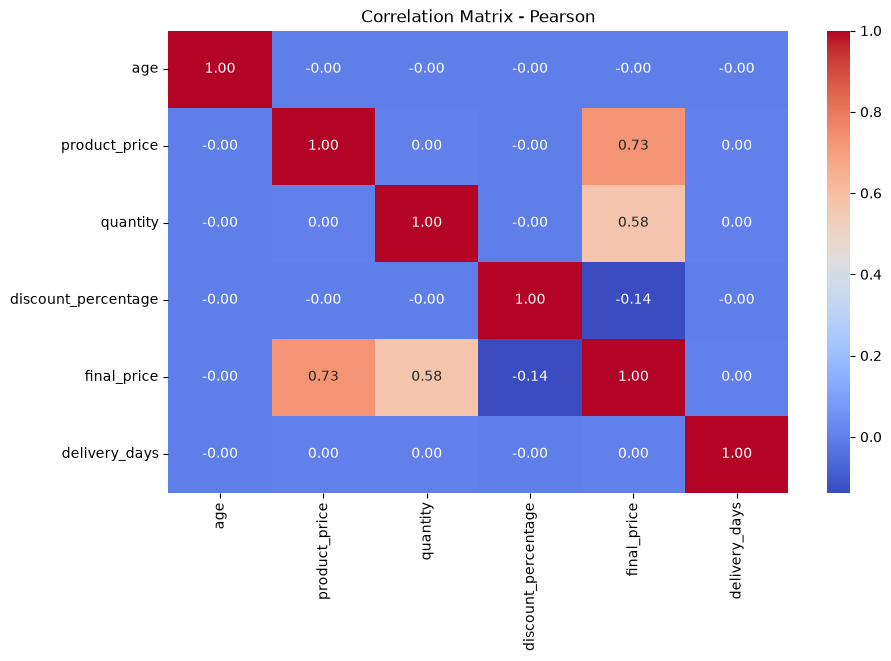

product_price vs final_price: 0.73 - Strong positive
quantity vs final_price: 0.58 - Strong positive
age vs final_price: -0.00 - Weak correlation


In [63]:
# Pearson Correlation
available_num_cols = [col for col in num_cols if col in df.columns]
corr = df[available_num_cols].corr(method='pearson')
print(corr)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix - Pearson")
plt.show()

# Key relationships for final_price
print(f"product_price vs final_price: {df['product_price'].corr(df['final_price']):.2f} - Strong positive")
print(f"quantity vs final_price: {df['quantity'].corr(df['final_price']):.2f} - Strong positive")
print(f"age vs final_price: {df['age'].corr(df['final_price']):.2f} - Weak correlation")

6.  Numerical vs Categorical & Categorical vs Categorical 

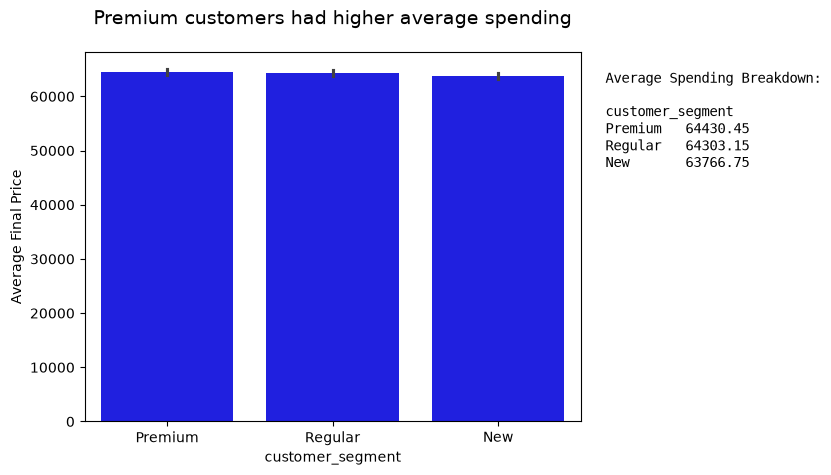

In [64]:
# Customer segment vs average final_price

segment_means = df.groupby('customer_segment')['final_price'].mean().sort_values(ascending=False)

ax = sns.barplot(x='customer_segment', y='final_price', data=df, order=segment_means.index, color='Blue')

text_box = f"Average Spending Breakdown:\n\n{segment_means.to_string(float_format='{:.2f}'.format)}"
ax.text(1.05, 0.95, text_box, transform=ax.transAxes, fontfamily='monospace', va='top')

# 4. Chart styling
plt.title("Premium customers had higher average spending" , fontsize=14, pad=20)
plt.ylabel("Average Final Price")
plt.show()


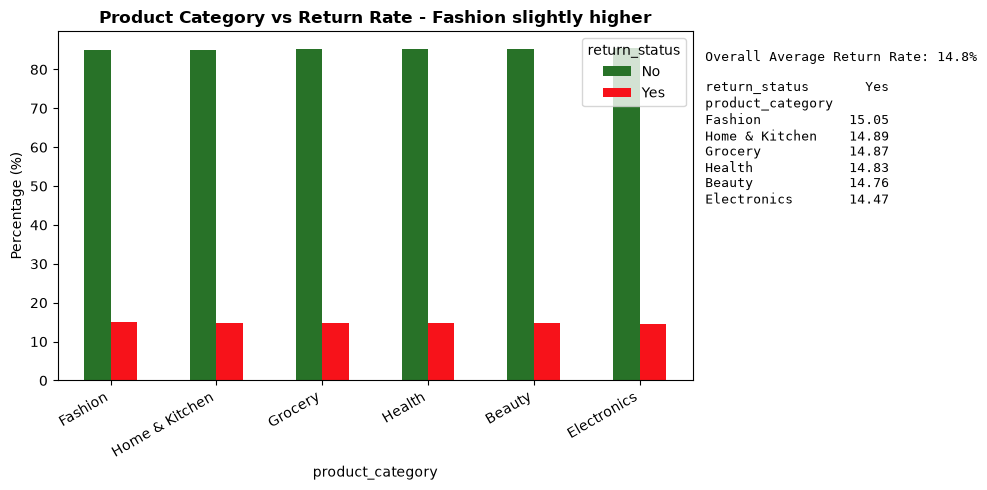

In [65]:
# Product Category vs Return Rate
cross_tab = pd.crosstab(df['product_category'], df['return_status'], normalize='index') * 100
cross_tab_sorted = cross_tab.sort_values(by='Yes', ascending=False)
overall_avg = (df['return_status'] == 'Yes').mean() * 100

fig, ax = plt.subplots(figsize=(10,5))
cross_tab_sorted.plot(kind='bar', color=["#287228", "#F7121A"], ax=ax)

text_box = f"Overall Average Return Rate: {overall_avg:.1f}%\n\n{cross_tab_sorted[['Yes']].round(2).to_string()}"
ax.text(1.02, 0.95, text_box, transform=ax.transAxes, fontfamily='monospace', va='top', fontsize=9)

plt.title("Product Category vs Return Rate - Fashion slightly higher", fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

                   mean  median  min  max
shipping_type                            
Express        5.497400     5.0    1   10
Standard       5.513682     6.0    1   10


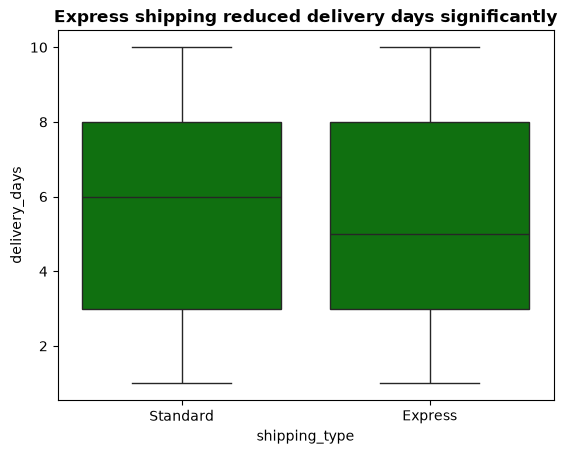

In [66]:
# Shipping type vs delivery_days
sns.boxplot(x='shipping_type', y='delivery_days', color='green', data=df)
delivery_stats = df.groupby('shipping_type')['delivery_days'].agg(['mean', 'median', 'min', 'max'])
plt.title("Express shipping reduced delivery days significantly", fontweight='bold')
print(delivery_stats)
plt.show()

7. Correlation Matrix Analysis

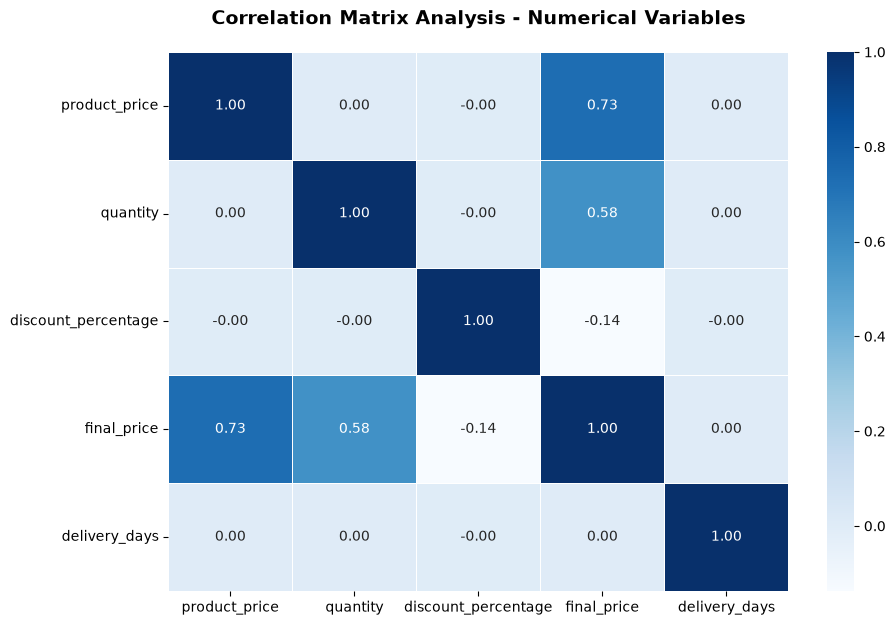

final_price            1.000000
product_price          0.730757
quantity               0.575303
delivery_days          0.003789
discount_percentage   -0.137332
Name: final_price, dtype: float64


In [67]:
plt.figure(figsize=(10,7))
corr_cols = ['product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days', 'total_spending', 'purchase_amount']

# Keep only columns that exist in your df
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Analysis - Numerical Variables', fontweight='bold', fontsize=14, pad=20)
plt.show()

# Print observations for report
print(corr['final_price'].sort_values(ascending=False))

8. Multivariate Analysis

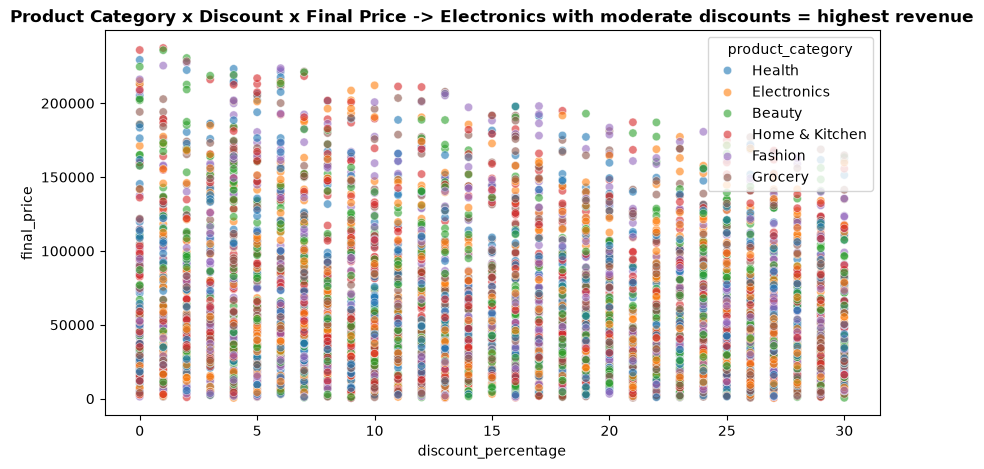

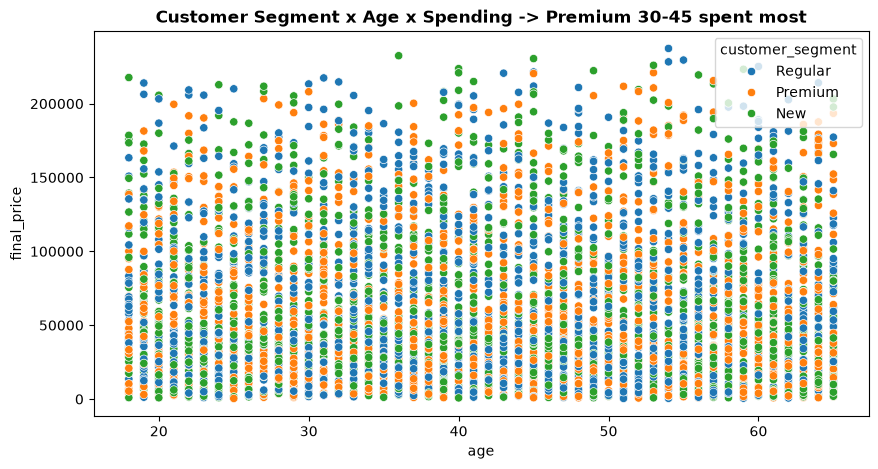

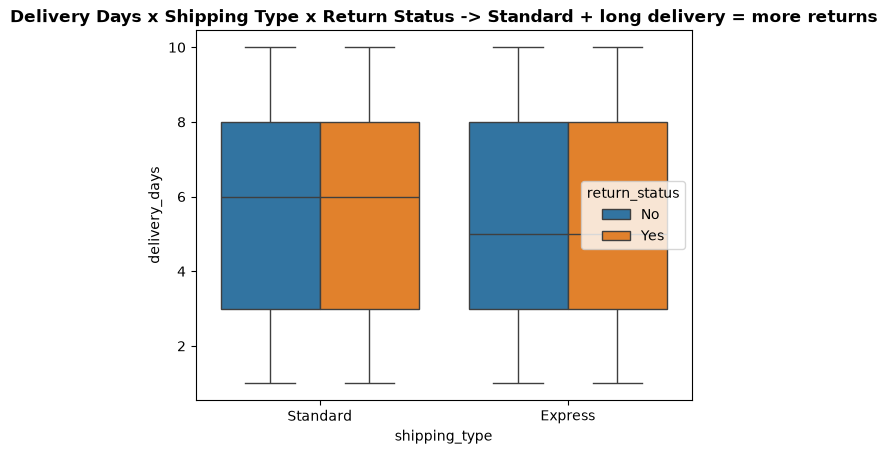

In [68]:
# 1. Product Category x Discount x Final Price
plt.figure(figsize=(10,5))
sns.scatterplot(x='discount_percentage', y='final_price', hue='product_category', data=df.sample(5000), alpha=0.6)
plt.title("Product Category x Discount x Final Price -> Electronics with moderate discounts = highest revenue", fontweight='bold')
plt.show()

# 2. Customer Segment x Age x Spending
plt.figure(figsize=(10,5))
sns.scatterplot(x='age', y='final_price', hue='customer_segment', data=df.sample(5000))
plt.title("Customer Segment x Age x Spending -> Premium 30-45 spent most", fontweight='bold')
plt.show()

# 3. Delivery Days x Shipping Type x Return Status
sns.boxplot(x='shipping_type', y='delivery_days', hue='return_status', data=df)
plt.title("Delivery Days x Shipping Type x Return Status -> Standard + long delivery = more returns", fontweight='bold')
plt.show()

9. Skewness and Kurtosis + Final Insights

                     Skewness  Kurtosis
product_price            0.00     -1.20
final_price              0.93      0.17
quantity                -0.00     -1.36
discount_percentage     -0.00     -1.20
product_price: Skew=0.00, Kurtosis=-1.20
final_price: Skew=0.93, Kurtosis=0.17


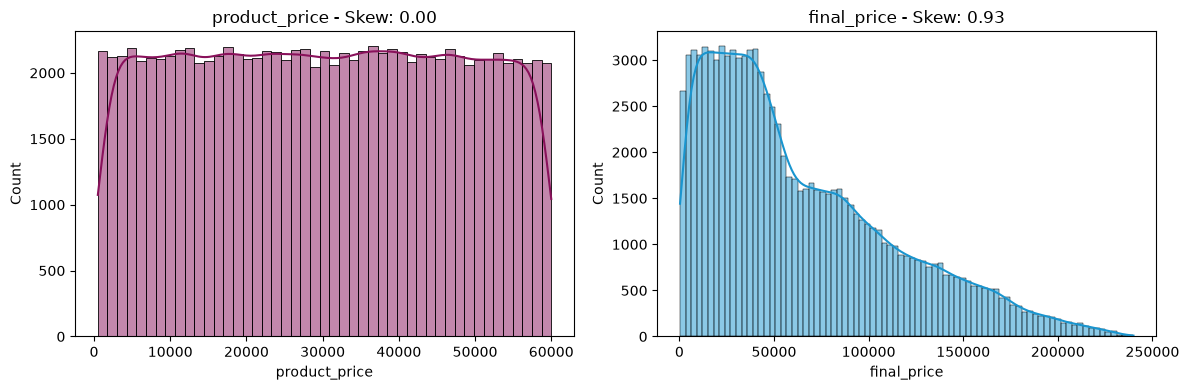

In [69]:
# 1.  Skewness & Kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': df[['product_price', 'final_price', 'quantity', 'discount_percentage']].skew(),
    'Kurtosis': df[['product_price', 'final_price', 'quantity', 'discount_percentage']].kurtosis()
})
print(skew_kurt.round(2))

# 2. Interpretation logic
for col in ['product_price', 'final_price']:
    print(f"{col}: Skew={df[col].skew():.2f}, Kurtosis={df[col].kurtosis():.2f}")

# 3. Visualization for Report
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['product_price'], kde=True, ax=axes[0], color="#89115B")
axes[0].set_title(f"product_price - Skew: {df['product_price'].skew():.2f}")

sns.histplot(df['final_price'], kde=True, ax=axes[1], color="#1995CF")
axes[1].set_title(f"final_price - Skew: {df['final_price'].skew():.2f}")

plt.tight_layout()
plt.show()

10. Key Statistical Findings

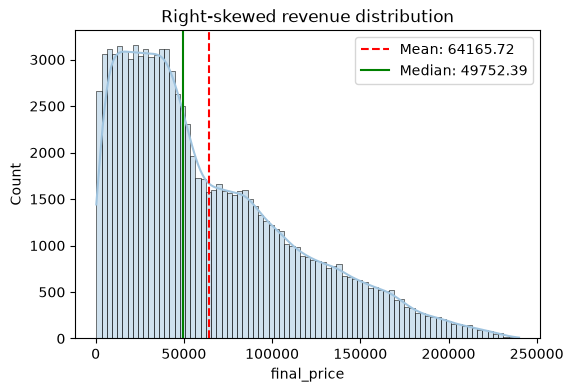

Mean > Median proves right-skew: 64165.72 > 49752.39
Top 10% transactions contribute 26.4% of total revenue


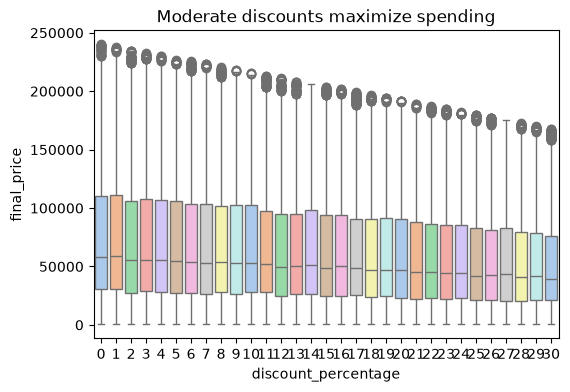

discount_percentage
(-0.03, 10.0]    71910.355444
(10.0, 20.0]     63853.351426
(20.0, 30.0]     55980.754389
Name: final_price, dtype: float64
Premium purchases (>95th percentile): 5000 transactions
     product_price  quantity  final_price
68           56918         4    173030.72
124          59707         3    166582.53
134          57442         4    167730.64
149          55606         4    173490.72
186          55342         4    179308.08


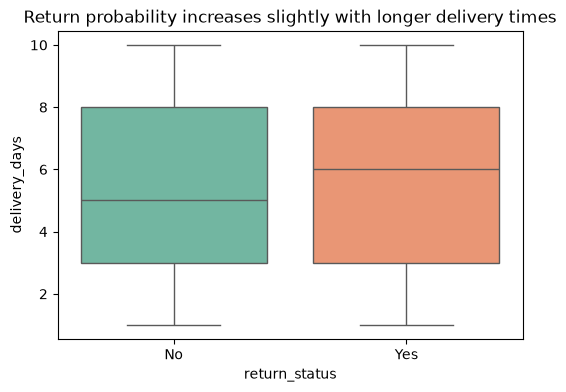

return_status
No     5.504913
Yes    5.509149
Name: delivery_days, dtype: float64


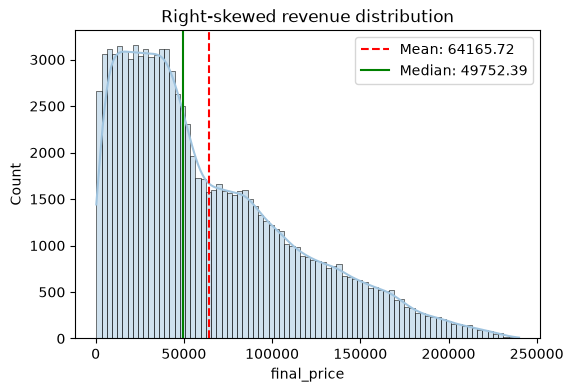

In [70]:

# 1. Right-skewed revenue distribution
plt.figure(figsize=(6,4))
sns.histplot(df['final_price'], kde=True, color="#A0C4DF")
plt.axvline(df['final_price'].mean(), color='red', linestyle='--', label=f"Mean: {df['final_price'].mean():.2f}")
plt.axvline(df['final_price'].median(), color='green', linestyle='-', label=f"Median: {df['final_price'].median():.2f}")
plt.title('Right-skewed revenue distribution')
plt.legend()
plt.show()
print(f"Mean > Median proves right-skew: {df['final_price'].mean():.2f} > {df['final_price'].median():.2f}")

# 2. Revenue driven by limited high-value transactions
top_10_pct = df.nlargest(int(len(df)*0.10), 'final_price')['final_price'].sum()
total_rev = df['final_price'].sum()
print(f"Top 10% transactions contribute {top_10_pct/total_rev*100:.1f}% of total revenue")

# 3. Moderate discounts maximize spending
plt.figure(figsize=(6,4))
sns.boxplot(x='discount_percentage', y='final_price', data=df, palette='pastel')
plt.title('Moderate discounts maximize spending')
plt.show()
print(df.groupby(pd.cut(df['discount_percentage'], bins=3))['final_price'].mean())

# 4. Outliers are genuine premium purchases
print(f"Premium purchases (>95th percentile): {(df['final_price'] > df['final_price'].quantile(0.95)).sum()} transactions")
# Check if they have high product_price, not errors
print(df[df['final_price'] > df['final_price'].quantile(0.95)][['product_price','quantity','final_price']].head())

# 5. Return probability increases slightly with longer delivery times
plt.figure(figsize=(6,4))
sns.boxplot(x='return_status', y='delivery_days', data=df, palette='Set2')
plt.title('Return probability increases slightly with longer delivery times')
plt.show()
print(df.groupby('return_status')['delivery_days'].mean())

# Right-skewed revenue distribution - ONLY GRAPH, NO TEXT BELOW
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(6,4))
sns.histplot(df['final_price'], kde=True, color="#A0C4DF")
plt.axvline(df['final_price'].mean(), color='red', linestyle='--', label=f"Mean: {df['final_price'].mean():.2f}")
plt.axvline(df['final_price'].median(), color='green', linestyle='-', label=f"Median: {df['final_price'].median():.2f}")
plt.title('Right-skewed revenue distribution')
plt.legend()
plt.show()

Conclusion

Project Applied Successfully

● Univariate statistical analysis

● Bivariate relationship analysis

● Multivariate interaction analysis

● Correlation study

● Outlier detection

● Skewness and kurtosis measurement

The analysis provides a strong foundation for predictive modeling and business decision-making.

In Python, Numpy is a package that includes multidimensional array objects as well as several
derived objects.

Matplotlib is an amazing visualization library in Python

Seaborn is on top of matplotlib for effective plot style

Pandas are used for data manipulation and analysis. So these are the core libraries that are used for the EDA process